# BMEA05 Signaler och system - Lab 1 


## 1. SciPy och NumPy
Se till att paketen som behövs är installerad genom att köra koden nedan.

In [17]:
%pip install -q numpy
%pip install -q scipy
%pip install -q matplotlib
%pip install -q pyqt6
%pip install -q sounddevice


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\46734\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Starta om kerneln (Tryck på "Restart"). Importera sedan de bibliotek som behövs för Lab 1 genom att köra koden nedan.

In [18]:
import numpy as np
import scipy.io

#För interaktiva plottar i separat fönster (med zoom och pan)
import matplotlib.pyplot as plt
%matplotlib qt

#För att kunna läsa in en WAV-fil 
import scipy.io.wavfile as wavfile

#För att kunna spela upp en vektor som ett ljud
import sounddevice as sd


## 2. EKG signal
### Uppgift 2.1
Filen *ekg.npz* innehåller en 10 sekunders 12-kanals EKG inspelning, samplad med samplingsfrekvens $Fs = 500$ Hz[1][2].
Läs in filen, och kontrollera dess innehåll.


1.	 Kalyakulina, A., Yusipov, I., Moskalenko, V., Nikolskiy, A., Kozlov, A., Kosonogov, K., Zolotykh, N., & Ivanchenko, M. (2020). Lobachevsky University Electrocardiography Database (version 1.0.0). PhysioNet. https://doi.org/10.13026/qweb-sr17.

2.	 Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220.


In [19]:
data = np.load("ekg.npz")

# Skriv ut alla variabelnamn
print("Variabler i filen:", list(data.keys()))

Variabler i filen: ['ekg', 'fs']


### Uppgift 2.2
EKG signalen är sparad i matrisen *ekg*. Vilken storlek har denna matris?

In [20]:
ekg = data['ekg']
print("EKG storlek:", ekg.shape)

EKG storlek: (12, 5000)


### Uppgift 2.3
Plotta avledning 1,2 och 3 av EKG signalen som funktion av sampelnummer $n$. 

In [21]:
# Skapa figur med 3 subplots som delar x-axel
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plotta första avledning
ax1.plot(ekg[0, :])
ax1.set_ylabel('I')
ax1.set_title('EKG')
ax1.grid()

# Plotta andra avledning
ax2.plot(ekg[1, :])
ax2.set_ylabel('II')
ax2.grid()

# Plotta tredje avledning
ax3.plot(ekg[2, :])
ax3.set_ylabel('III')
ax3.set_xlabel('n')
ax3.grid()

plt.tight_layout()
plt.show()

### Uppgift 2.4
Plotta istället EKG signalen som funktion av tid i sekunder. Skapa en tidsvektor $t$ med samma längd som EKG signalen, där avståndet mellan tidpunkterna motsvarar samplingsperioden $T=\frac{1}{Fs}$.  
Plotta sedan avledning 1,2 och 3 av EKG signalen som funktion av $t$.
Vilken hjärtfrekvens har personen?

In [22]:
# Definiera samplings frekvens (Fs)
Fs = 500 

# Skapa tidsvektor
t = np.arange(0, ekg.shape[1] / Fs, 1/ Fs)
 
# Skapa figur med 3 subplots som delar x-axel
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plotta första avledning
ax1.plot(t,ekg[0, :])
ax1.set_ylabel('I')
ax1.set_title('EKG')
ax1.grid()

# Plotta andra avledning
ax2.plot(t,ekg[1, :])
ax2.set_ylabel('II')
ax2.grid()

# Plotta tredje avledning
ax3.plot(t,ekg[2, :])
ax3.set_ylabel('III')
ax3.set_xlabel('t(s)');
ax3.grid()

plt.tight_layout()
plt.show()

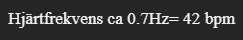

### Uppgift 2.5
Vid AD omvandlingen har amplituden på EKG signalen centrerats och skalats och att rymmas i intervallet [-32767, 32767]. För plotta EKG signalen i mV behöver vi därför veta vilken offset och skalning som använts vid AD omvandlingen. Denna informationen finns i header filen ekg.hea, där vi kan t.ex. utläsa att avledning I har offset -25816 och skalningsfaktor 381900, avledning II har offset -23964 och skalningsfaktor 54340 och avledning III har offset 18530 och skalningsfaktor 53323. För att plotta EKG avledning I, II och III i mV behöver vi alltså korrigera för detta.
Varför har man använt olika offset och skalning i AD omvandingen av de olika avledningarna? (förklara i termer av dynamik, upplösning och antal bitar i AD omvandlingen)

In [23]:
# Casta om till float64 för att undvika overflow
ekg = ekg.astype(np.float64)

# Skapa figur med 3 subplots som delar x-axel
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plotta första avledning
ax1.plot(t,(ekg[0, :]+25816)/38190)
ax1.set_ylabel('I (mV)')
ax1.set_title('EKG')
ax1.grid()

# Plotta andra avledning
ax2.plot(t,(ekg[1, :]+23964)/54340)
ax2.set_ylabel('II (mV)')
ax2.grid()

# Plotta tredje avledning
ax3.plot(t,(ekg[2, :]-18530)/53323)
ax3.set_ylabel('III (mV)')
ax3.set_xlabel('t(s)')
ax3.grid()

plt.tight_layout()
plt.show()

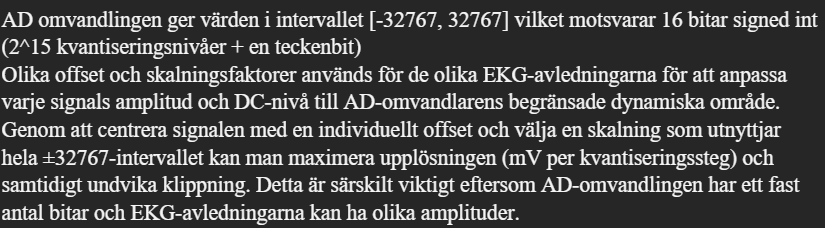

## 3. Ljudsignal
### Uppgift 3.1
Filen *Harvard_sentence_ex.wav* innehåller en ljudsignal, där en kvinnlig röst som läser en mening från de så kallade Harvard sentences, som är en standardiserad uppsättning meningar som brukar användas för utveckling och testning av audioutrustning och algoritmer [3]. 
Läs in file och kontrollera dess innehåll.

3.	Demonte, P.. (2019). HARVARD speech corpus - audio recording 2019 (Version 1). University of Salford. https://doi.org/10.17866/rd.salford.c.4437578.v1 ([u'http://www-2.cs.cmu.edu/afs/cs.cmu.edu/project/fgdata/OldFiles/Recorder.app/utterances/Type1/harvsents.txt'])


In [36]:
# Läs in ljudfilen
Fs, x = wavfile.read('Harvard_sentence_ex.wav')

# Kolla samplingsfrekvens och storlek på ljuddata
print("Samplingsfrekvens: ", Fs)
print("Storlek på ljuddata: ", x.shape)


Samplingsfrekvens:  48000
Storlek på ljuddata:  (172001,)


### Uppgift 3.2 
Ljudsignalen är samplad med Fs=48000Hz. Spela upp signalen och lyssna på den. Använd samma samplingsfrekvens vid rekonstruktionen som använts vid samplingen.

In [29]:
# Normera vektorn med ljudsampel till intervallet [-1, 1] för uppspelning
x_normalized = x / np.max(np.abs(x))

# Spela upp ljudet
sd.play(x_normalized, Fs)

# Vänta till uppspelningen slutat
sd.wait()

### Uppgift 3.3
Spela upp signalen med någon annan rekonstruktionsfrekvens *Fs_mod* och lyssna på den. Testa både med högre och lägre frekvenser, t.ex. dubbla eller halva samplingsfrekvensen. Vad händer? 

In [30]:
#Annan samplingfrekvens
Fs_mod=48000/0.5

# Spela upp ljudet
sd.play(x_normalized, Fs_mod)

# Vänta till uppspelningen slutat
sd.wait()

### Uppgift 3.4
Plotta ljudsignalen som funktion av tid i sekunder.

In [38]:
# Skapa tidsvektor
t = np.arange(0, x.shape[0] / Fs, 1 / Fs)

# Skapa figur
plt.figure(figsize=(10, 8))

# Plotta ljudet
plt.plot(t,x)
plt.title('Ljudsignal')
plt.grid()
plt.xlabel('t(s)')

plt.tight_layout()
plt.show()

### Uppgift 3.5
Zooma in plotten för att visa signalen t.ex. mellan t=0.2s och t=0.3s, eller något annat tidssegment där signalen är periodisk. Dessa segment innehåller tonande ljud. Lyssna på ditt utvalda segment för att kontrollera detta.
Vilken periodtid har ljudsignalen i detta segment? Vilken frekvens motsvarar detta? 

In [39]:
# Hitta index för start och slut
n_start = np.argmax(t > 0.2)  # första index där t > 0.2
n_end = np.argmax(t > 0.3)    # första index där t > 0.3

# Extrahera segmentet
x_seg = x[n_start:n_end]

# Normalmera vektorn med ljudsampel till intervallet [-1, 1]
x_seg_normalized = x_seg / np.max(np.abs(x_seg))

# Spela upp segmentet
sd.play(x_seg_normalized, Fs)
sd.wait()

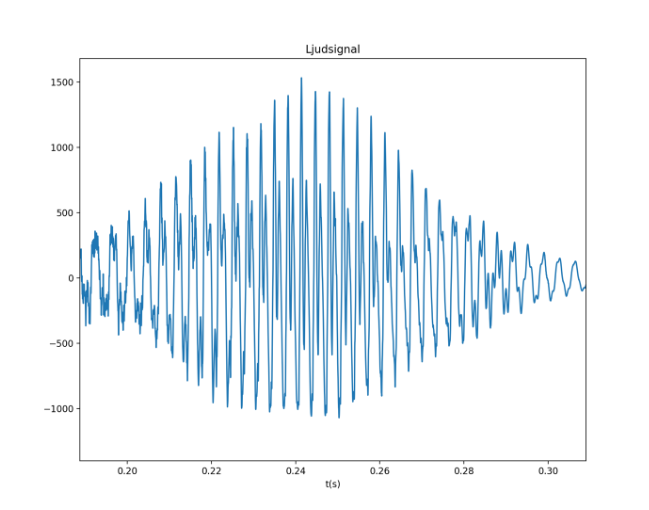

T=3.33ms (30 perioder på 0.1s)

F=300 Hz

### Uppgift 3.6
Går det att få den kvinnliga rösten att det låta som en manlig röst genom att ändra frekvensen som används vid rekonstruktionen? Vilken frekvens ska i så fall användas? Hur låter det?

Ledtråd: Tonande tal hos en vuxen man har typiskt en grundtonsfrekvens mellan 85 och 180 Hz.

In [46]:
#Ange ändrad samplignsfrekvens här
factor = 180/300
Fs_mod=48000*factor

# Spela upp ljudet
sd.play(x_normalized, Fs_mod)

# Vänta till uppspelningen slutat
sd.wait()

## 4.	Cosinussignal 
### Uppgift 4.1
Skapa en tidsdiskret cosinussignal av längd $N=1000$ med normerad frekvens $f_1=0.1$ och en lika lång tidsdiskret cosinussignal med normerad frekvens $f_2=0.9$.

In [47]:
N = 1000  
f1 = 0.1    
f2 = 0.9   

# Skapa en vektor med index från 0 till N
n = np.arange(0, N + 1)

# Skapa cosinussignalerna
x1 = np.cos(2 * np.pi * f1 * n) 
x2 = np.cos(2 * np.pi * f2 * n) 

### Uppgift 4.2
Spela upp och lyssna på signalerna. Använd rekonstruktionsfrekvens Fs=4000 Hz. Vad hör du? 

In [ ]:
# Rekonstruktionsfrekvens
Fs = 4000

# Spela upp cosinussignal x_1
sd.play(x1, Fs)

# Vänta till uppspelningen slutat
sd.wait() 

# Spela upp cosinussignal x_2
sd.play(x2, Fs)

# Vänta till uppspelningen slutat
sd.wait()


# Man hör en frekvens med 400Hz i båda fallen även fast de har olika normerade frekvenser. 
# Detta beror på att den högre frekvensen (f2) faltas ner till 400Hz när den samplas med Fs=4000Hz, vilket gör att båda signalerna låter lika.

### Uppgift 4.3 
Plotta de första 100 samplen av respektive cosinussignal. 
Vad ser du? 
Vad har hänt?

In [ ]:
#  Skapa figur
plt.figure(figsize=(10, 8))

# Stem plot för x1
plt.stem(n[:100], x1[:100], linefmt='b-', markerfmt='bo', basefmt='k-', label='x1')

# Stem plot för x2
plt.stem(n[:100], x2[:100], linefmt='r:', markerfmt='*r', basefmt='k-', label='x2')
plt.xlabel('n')
plt.grid()

plt.tight_layout()
plt.show()

# De tidsdiskreta signalerna x1 och x2 är identiska pga vikning

### Uppgift 4.4
Testa även att skapa, lyssna på och plotta cosinussignaler med andra frekvenser. 
Vilken är den högsta möjliga frekvensen? 
Vilka normerade frekvenser ger identiska cosinussignaler?

In [60]:
N = 1000   
f1 = 0.8     
f2 = 0.2   


# Skapa en vektor med index från 0 till N 
n = np.arange(0, N + 1)  

# Skapa cosinussignalerna 
x1 = np.cos(2 * np.pi * f1 * n)  
x2 = np.cos(2 * np.pi * f2 * n)  


#  Skapa figur 
plt.figure(figsize=(10, 8)) 

# Stem plot för x1 
plt.stem(n[:100], x1[:100], linefmt='b-', markerfmt='bo', basefmt='k-', label='x1') 

# Stem plot för x2 
plt.stem(n[:100], x2[:100], linefmt='r:', markerfmt='*r', basefmt='k-', label='x2') 
plt.xlabel('n') 
plt.grid() 

# Högst möjliga normerade frekvens f=0.5
# Normerad frekvens f2 = +- f1 + k där k är ett heltal ger identiska cosinussignaler